In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO BOILER → AC OPPORTUNITY CUSTOMERS
print("\n🎯 FILTERING TO BOILER → AC OPPORTUNITY")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with boiler
has_boiler = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Chaudière' in x.values
)

# Get customers with AC
has_ac = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Climatisation' in x.values
)

# Boiler → AC opportunity: has boiler, no AC
boiler_to_ac_ids = has_boiler[has_boiler & (~has_ac)].index.tolist()

# Filter data
df_quotes_boiler_ac = df_quotes[df_quotes['numero_compte'].isin(boiler_to_ac_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Boiler → AC opportunity: {len(boiler_to_ac_ids):,} customers")
print(f"Quotes: {len(df_quotes_boiler_ac):,}")

# Save to file
df_quotes_boiler_ac.to_csv('cleaned_quote_data_boiler_ac.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_boiler_ac.csv")


🎯 FILTERING TO BOILER → AC OPPORTUNITY
Original customers: 23,888
Boiler → AC opportunity: 7,413 customers
Quotes: 10,326

✅ Saved to cleaned_quote_data_boiler_ac.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_boiler_ac.csv')

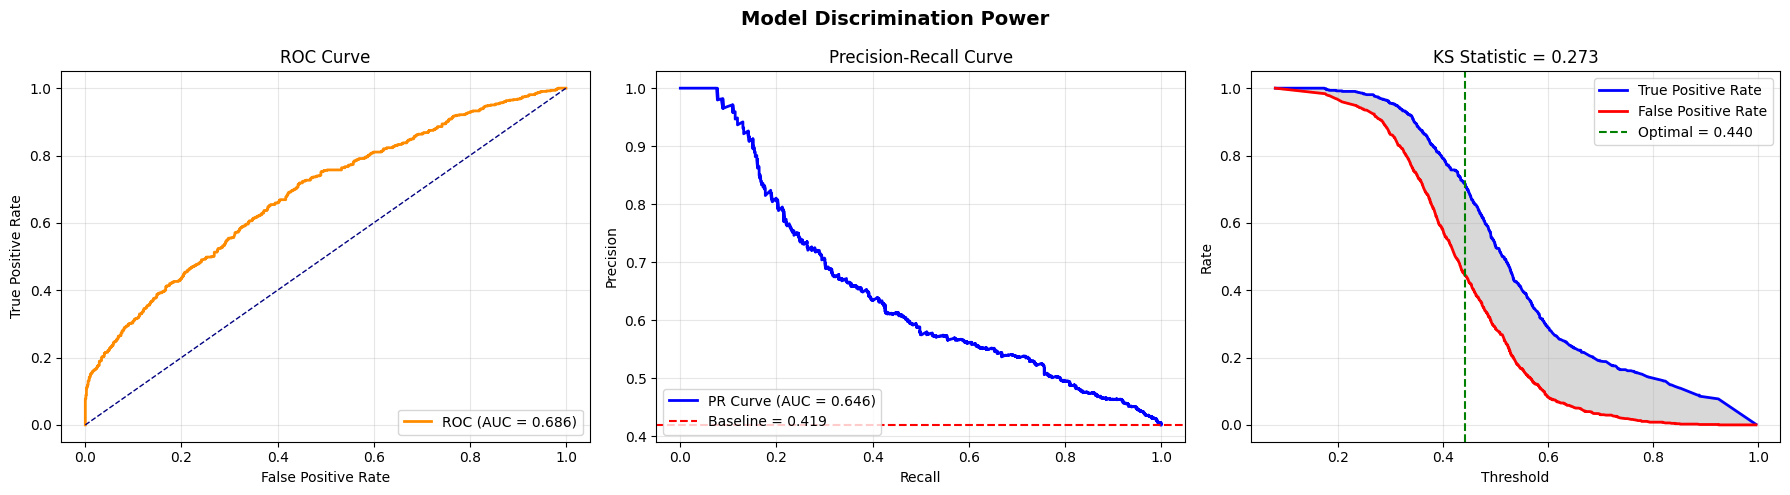

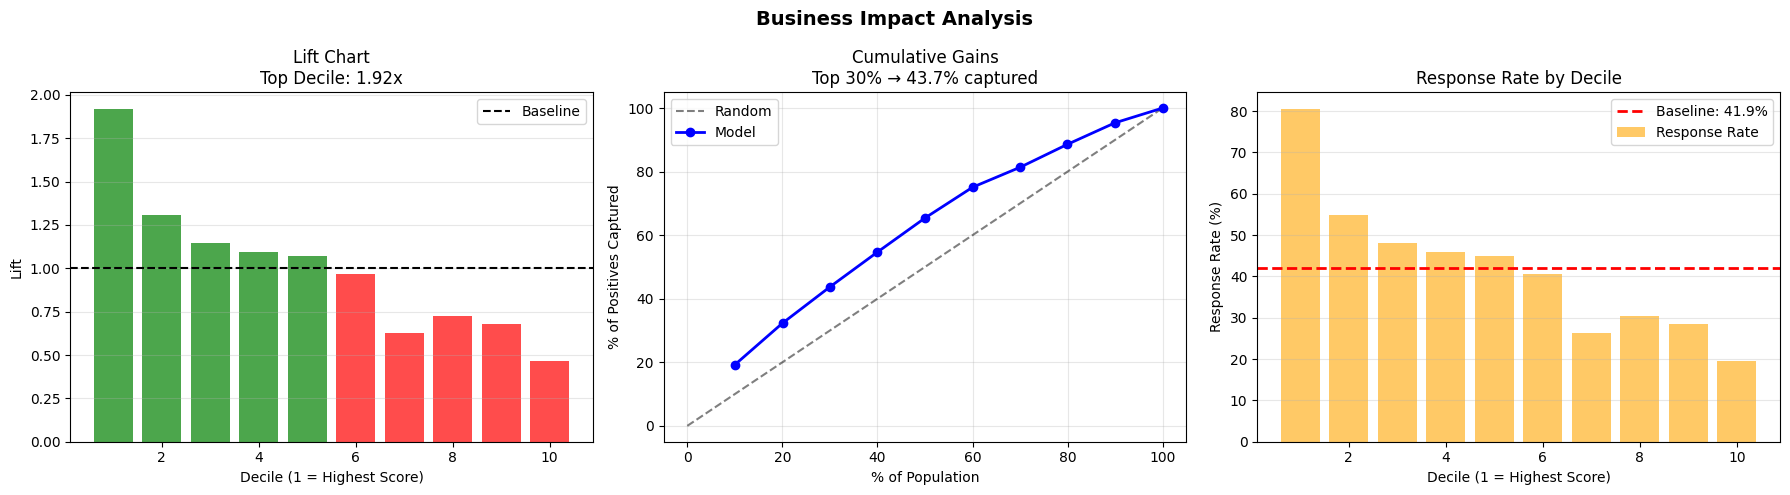

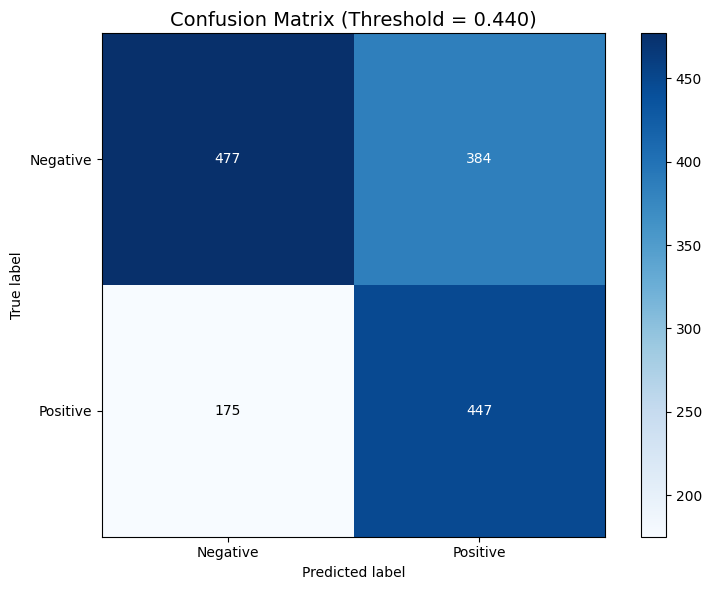


🔍 COMPREHENSIVE ERROR ANALYSIS
COMPREHENSIVE ERROR ANALYSIS

📊 1. BASIC ERROR METRICS
------------------------------------------------------------
Confusion Matrix:
  True Negatives:     615 (Correctly rejected)
  False Positives:    246 (Predicted YES, actual NO) ← WASTED EFFORT
  False Negatives:    294 (Predicted NO, actual YES) ← MISSED OPPORTUNITIES
  True Positives:     328 (Correctly predicted)

Error Analysis:
  • Total errors: 540 (36.4% of predictions)
  • False Positive rate: 16.6% (wasted sales effort)
  • False Negative rate: 19.8% (missed conversions)

📈 2. PREDICTION CONFIDENCE ANALYSIS
------------------------------------------------------------
Accuracy by Confidence Level:
  • Very Low   confidence: 81.0% accurate (147 predictions)
  • Low        confidence: 70.9% accurate (351 predictions)
  • Medium     confidence: 53.8% accurate (736 predictions)
  • High       confidence: 58.5% accurate (106 predictions)
  • Very High  confidence: 81.8% accurate (143 predictions)

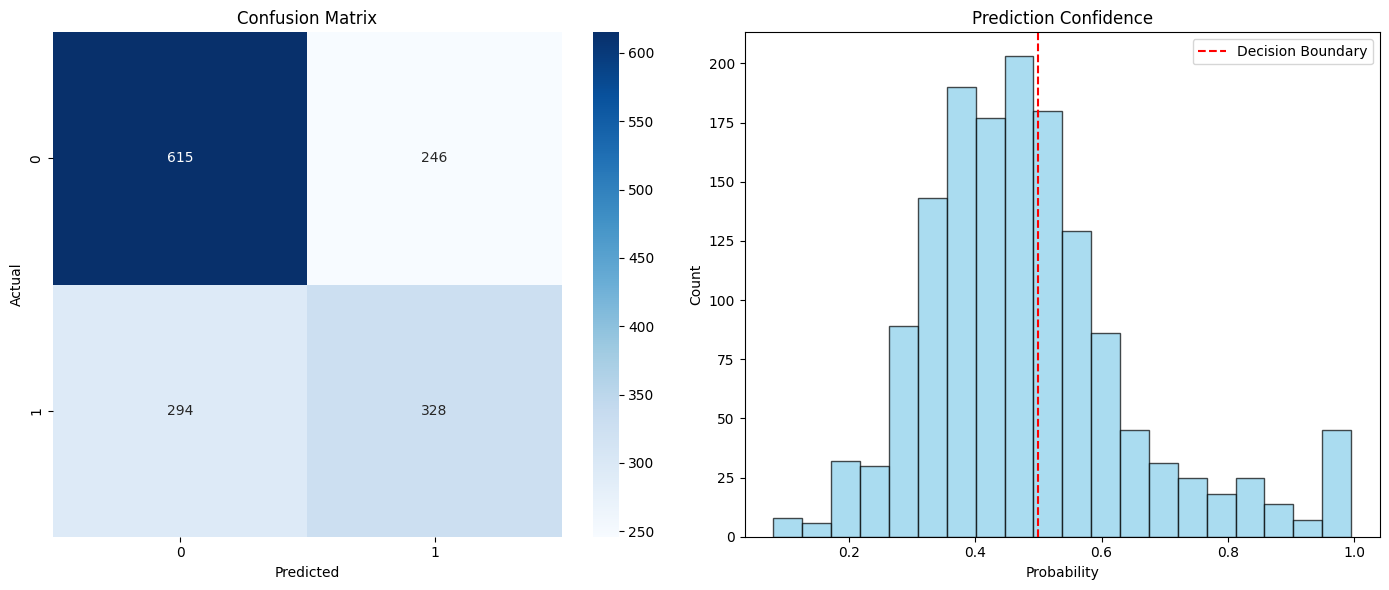

In [4]:
with redirect_stdout(open('/dev/null', 'w')):
    result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])